# Machine Learning Lab: Support Vector Machines (SVM)

**Role of this notebook:** teaching notebook for a hands-on ML lab. Every major idea is paired with code and a visualization.



## 0. Imports and reproducibility

We will use scikit-learn for **dataset generation, comparison models, and the library implementation**. The actual scratch SVM classifier will be written using NumPy.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles, make_blobs, load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)

print("NumPy version:", np.__version__)
import sklearn
print("scikit-learn version:", sklearn.__version__)

NumPy version: 2.1.3
scikit-learn version: 1.6.1


# Part I — Why do we need SVM?

A common but incomplete explanation is: **“SVM was invented because logistic regression fails.”** That is not the real idea.

The key SVM question is:

> If many decision boundaries classify the training data correctly, **which boundary should we choose?**

SVM chooses a boundary that maximizes the distance to the closest training points. This is the **maximum-margin principle**.

The classic support-vector network formulation by Cortes and Vapnik (1995) also extended the idea to non-separable data and nonlinear feature mappings.




Consider an intentionally simple dataset. Several vertical lines classify every training point correctly. Accuracy alone cannot tell us which separator is safer.

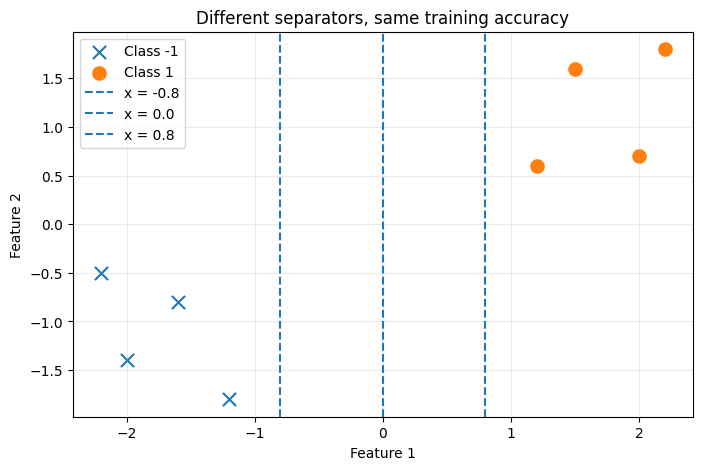

In [ ]:
X_demo = np.array([
    [-2.2, -0.5], [-2.0, -1.4], [-1.6, -0.8], [-1.2, -1.8],
    [ 1.2,  0.6], [ 1.5,  1.6], [ 2.0,  0.7], [ 2.2,  1.8]
])
y_demo = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

plt.figure(figsize=(8, 5))
for label, marker in [(-1, 'x'), (1, 'o')]:
    pts = X_demo[y_demo == label]
    plt.scatter(pts[:, 0], pts[:, 1], marker=marker, s=90, label=f"Class {label}")

for boundary in [-0.8, 0.0, 0.8]:
    plt.axvline(boundary, linestyle='--', label=f"x = {boundary}")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Different separators, same training accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [ ]:
def vertical_separator_stats(X, y, boundary):
    pred = np.where(X[:, 0] >= boundary, 1, -1)
    acc = np.mean(pred == y)
    # Distance from a point to vertical line x = boundary is |x - boundary|.
    min_distance = np.min(np.abs(X[:, 0] - boundary))
    return acc, min_distance

rows = []
for boundary in [-0.8, 0.0, 0.8]:
    acc, margin_to_nearest_point = vertical_separator_stats(X_demo, y_demo, boundary)
    rows.append([boundary, acc, margin_to_nearest_point])

pd.DataFrame(rows, columns=["Boundary x=c", "Training accuracy", "Nearest-point distance"])

,Boundary x=c,Training accuracy,Nearest-point distance
0,-0.8,1.0,0.4
1,0.0,1.0,1.2
2,0.8,1.0,0.4


### What should students notice?
All three separators achieve the same training accuracy, but the center separator has the largest distance to the closest points.

That distance is important because a very small perturbation can flip a point when the boundary lies too close to the data. SVM formalizes this intuition by maximizing the margin.

## 2. A linear model can also fail because the geometry itself is nonlinear

Now we create the classic two-moons dataset. A straight line is not flexible enough. We compare:

- Logistic regression: linear decision boundary.
- SVM with an RBF kernel: nonlinear decision boundary.

This motivates the **kernel** part of SVM, but kernels will come later. First we must understand the linear SVM.

In [ ]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.18, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons, test_size=0.30, random_state=42, stratify=y_moons
)

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
rbf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=2.0, gamma="scale"))
])

log_model.fit(X_train_m, y_train_m)
rbf_model.fit(X_train_m, y_train_m)

print("Logistic Regression test accuracy:", round(log_model.score(X_test_m, y_test_m), 3))
print("RBF-SVM test accuracy:", round(rbf_model.score(X_test_m, y_test_m), 3))

Logistic Regression test accuracy: 0.856
RBF-SVM test accuracy: 0.933


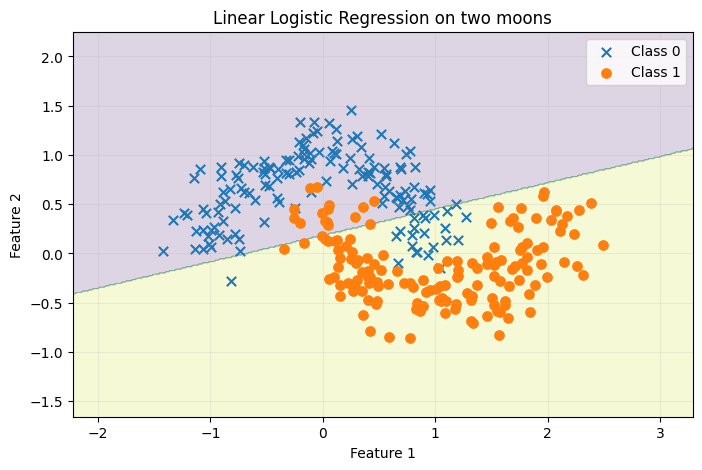

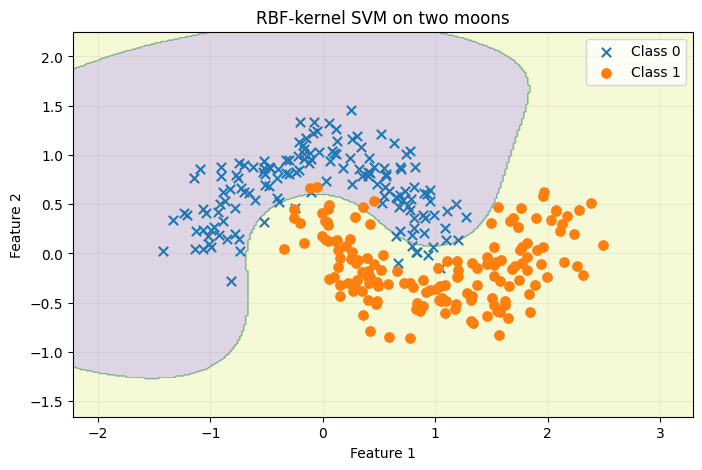

In [ ]:
def plot_decision_regions(model, X, y, title, resolution=300):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, zz, alpha=0.18)
    for label, marker in [(0, 'x'), (1, 'o')]:
        pts = X[y == label]
        plt.scatter(pts[:, 0], pts[:, 1], marker=marker, s=45, label=f"Class {label}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_decision_regions(log_model, X_moons, y_moons, "Linear Logistic Regression on two moons")
plot_decision_regions(rbf_model, X_moons, y_moons, "RBF-kernel SVM on two moons")

# Part II — SVM geometry from first principles

## 3. The separating hyperplane

For a linear classifier:

$$
f(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b
$$

Prediction is based on the sign:

$$
\hat{y} = \operatorname{sign}(\mathbf{w}^T\mathbf{x}+b)
$$

The decision boundary is where:

$$
\mathbf{w}^T\mathbf{x}+b = 0
$$

The vector $\mathbf{w}$ is perpendicular to the decision boundary.

## 4. Margin and support vectors

For labels $y_i\in\{-1,+1\}$, a correctly classified point should satisfy:

$$
y_i(\mathbf{w}^T\mathbf{x}_i+b) > 0
$$

SVM chooses a convenient scaling so the closest correctly placed points satisfy:

$$
y_i(\mathbf{w}^T\mathbf{x}_i+b) \ge 1
$$

The two margin boundaries are:

$$
\mathbf{w}^T\mathbf{x}+b = +1
$$

and

$$
\mathbf{w}^T\mathbf{x}+b = -1
$$

The distance between them is:

$$
\boxed{\frac{2}{\|\mathbf{w}\|}}
$$

Therefore, maximizing the margin is equivalent to minimizing $\|\mathbf{w}\|$.

The quantity $y_i f(\mathbf{x}_i)$ is often called the **functional margin**. Because multiplying both $\mathbf{w}$ and $b$ by a constant changes that number without moving the decision boundary, the distance-aware **geometric margin** divides by $\|\mathbf{w}\|$:

$$
\frac{y_i(\mathbf{w}^T\mathbf{x}_i+b)}{\|\mathbf{w}\|}
$$

The observations nearest to the boundary — the ones that touch or violate the margin — are the **support vectors**. They are the critical points that determine the classifier.

## 5. Hard-margin SVM

If the training set is perfectly linearly separable:

$$
\min_{\mathbf{w},b} \frac{1}{2}\|\mathbf{w}\|^2
$$

subject to:

$$
y_i(\mathbf{w}^T\mathbf{x}_i+b)\ge 1 \quad \forall i
$$

But real data usually contain overlap, noise, and outliers. Hard-margin SVM can become impossible or overly sensitive.

## 6. Soft-margin SVM and slack

Soft-margin SVM allows margin violations using slack variables $\xi_i$:

$$
\min_{\mathbf{w},b,\xi}\frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i
$$

subject to:

$$
y_i(\mathbf{w}^T\mathbf{x}_i+b)\ge 1-\xi_i, \qquad \xi_i\ge0
$$

Interpretation of $C$:

- **Large $C$:** violations are expensive → model tries hard to classify training points correctly → narrower margin may result.
- **Small $C$:** violations are tolerated more → stronger regularization → wider, softer margin may result.

This trade-off is central to practical SVM use.

## 7. Hinge loss: the loss function behind soft-margin classification

For one observation:

$$
L_{hinge}=\max(0, 1-yf(\mathbf{x}))
$$

Let $m=yf(\mathbf{x})$ be the signed margin score.

- If $m\ge1$, hinge loss is zero.
- If $0<m<1$, prediction is correct but inside the margin.
- If $m<0$, the point is misclassified.

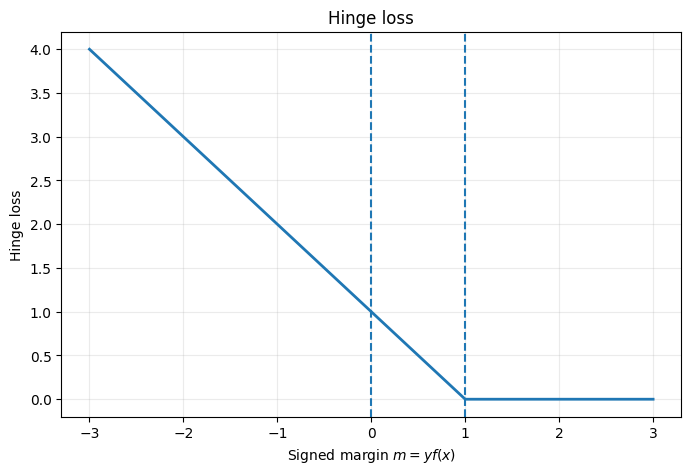

In [ ]:
margin_scores = np.linspace(-3, 3, 500)
hinge = np.maximum(0, 1 - margin_scores)

plt.figure(figsize=(8, 5))
plt.plot(margin_scores, hinge, linewidth=2)
plt.axvline(0, linestyle='--')
plt.axvline(1, linestyle='--')
plt.xlabel(r"Signed margin $m = y f(x)$")
plt.ylabel("Hinge loss")
plt.title("Hinge loss")
plt.grid(alpha=0.25)
plt.show()

# Part III — Linear SVM from scratch

We will optimize this practical primal objective:

$$
J(\mathbf{w},b)=\frac{1}{2}\|\mathbf{w}\|^2 + C\cdot\frac{1}{n}\sum_{i=1}^{n}\max\left(0,1-y_i(\mathbf{w}^T\mathbf{x}_i+b)\right)
$$

This is not the same solver used internally by `SVC`; it is a transparent educational implementation using **sub-gradient descent**.

For a point with $y_if_i\ge1$, its hinge-loss gradient is zero. For a violating point with $y_if_i<1$, it contributes a gradient that pushes the boundary in the correct direction.

For a batch of $n$ samples, let $V=\{i:y_i f_i<1\}$ be the violating set. A valid sub-gradient is:

$$
\nabla_{\mathbf{w}}J = \mathbf{w} - \frac{C}{n}\sum_{i\in V} y_i\mathbf{x}_i
$$

$$
\frac{\partial J}{\partial b} = -\frac{C}{n}\sum_{i\in V} y_i
$$

The code below implements these equations directly.

In [ ]:
class LinearSVMFromScratch:
    """ linear soft-margin SVM using batch sub-gradient descent."""

    def __init__(self, learning_rate=0.01, C=1.0, epochs=1000, snapshot_epochs=None):
        self.learning_rate = learning_rate
        self.C = C
        self.epochs = epochs
        self.snapshot_epochs = set(snapshot_epochs or [])
        self.loss_history_ = []
        self.snapshots_ = {}

    def _objective(self, X, y):
        scores = X @ self.w_ + self.b_
        hinge = np.maximum(0.0, 1.0 - y * scores)
        return 0.5 * np.dot(self.w_, self.w_) + self.C * hinge.mean()

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Scratch SVM expects labels encoded as -1 and +1.")

        n_samples, n_features = X.shape
        self.w_ = np.zeros(n_features, dtype=float)
        self.b_ = 0.0

        for epoch in range(1, self.epochs + 1):
            scores = X @ self.w_ + self.b_
            margins = y * scores
            viol = margins < 1

            # Gradient of 0.5||w||^2 is simply w.
            grad_w = self.w_.copy()
            grad_b = 0.0

            if np.any(viol):
                # Objective uses mean hinge loss over ALL n samples, so divide by n_samples.
                grad_w -= self.C * np.sum(y[viol, None] * X[viol], axis=0) / n_samples
                grad_b -= self.C * np.sum(y[viol]) / n_samples

            self.w_ -= self.learning_rate * grad_w
            self.b_ -= self.learning_rate * grad_b

            loss = self._objective(X, y)
            self.loss_history_.append(loss)

            if epoch in self.snapshot_epochs:
                self.snapshots_[epoch] = (self.w_.copy(), float(self.b_))

        return self

    def decision_function(self, X):
        return np.asarray(X) @ self.w_ + self.b_

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)

    def margin_mask(self, X, y, tolerance=0.05):
        margins = y * self.decision_function(X)
        return margins <= (1.0 + tolerance)

## 8. Build a dataset for the scratch implementation

We deliberately use a little overlap so the soft-margin behavior is visible.

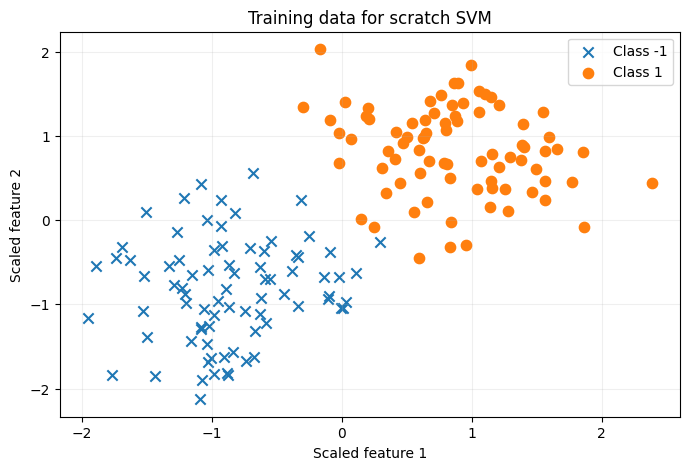

In [ ]:
X_lin, y01_lin = make_blobs(
    n_samples=160,
    centers=[(-1.8, -1.4), (1.8, 1.4)],
    cluster_std=[1.05, 1.05],
    random_state=7
)
y_lin = np.where(y01_lin == 0, -1, 1)

# Standardize manually for transparent scratch training.
mean_lin = X_lin.mean(axis=0)
std_lin = X_lin.std(axis=0)
X_lin_scaled = (X_lin - mean_lin) / std_lin

plt.figure(figsize=(8, 5))
for label, marker in [(-1, 'x'), (1, 'o')]:
    pts = X_lin_scaled[y_lin == label]
    plt.scatter(pts[:, 0], pts[:, 1], marker=marker, s=55, label=f"Class {label}")
plt.xlabel("Scaled feature 1")
plt.ylabel("Scaled feature 2")
plt.title("Training data for scratch SVM")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 9. Train the scratch SVM and watch the objective decrease

In [ ]:
scratch_svm = LinearSVMFromScratch(
    learning_rate=0.02,
    C=2.0,
    epochs=1200,
    snapshot_epochs=[1, 5, 20, 100, 400, 1200]
)
scratch_svm.fit(X_lin_scaled, y_lin)

pred_lin = scratch_svm.predict(X_lin_scaled)
print("Training accuracy:", round(accuracy_score(y_lin, pred_lin), 3))
print("Learned w:", scratch_svm.w_)
print("Learned b:", scratch_svm.b_)
print("Approximate full margin width 2/||w||:", round(2 / np.linalg.norm(scratch_svm.w_), 3))

Training accuracy: 0.994
Learned w: [0.573824   0.54653706]
Learned b: 0.0009999999999999948
Approximate full margin width 2/||w||: 2.524


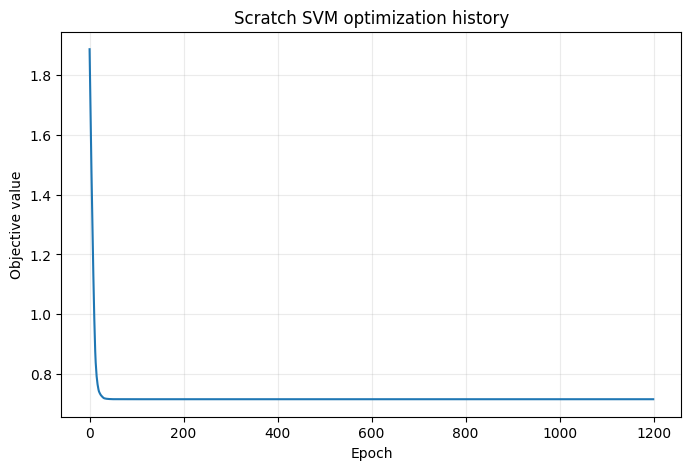

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(scratch_svm.loss_history_)
plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.title("Scratch SVM optimization history")
plt.grid(alpha=0.25)
plt.show()

## 10. Visualize boundary, margins, and support-vector candidates

For the scratch model, we call points with $y_if(x_i)\le 1.05$ **support-vector candidates**. Exact solver conventions differ, but this is the right geometric intuition.

Support-vector candidates: 93 out of 160


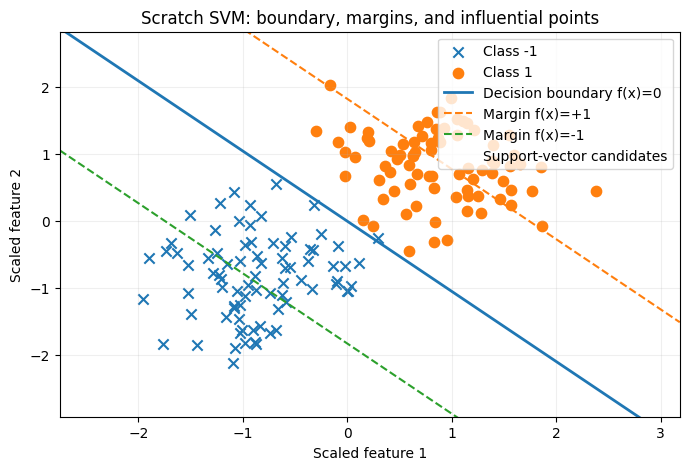

In [ ]:
def plot_linear_svm_geometry(X, y, w, b, title, support_mask=None):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    xs = np.linspace(x_min, x_max, 400)

    plt.figure(figsize=(8, 5))
    for label, marker in [(-1, 'x'), (1, 'o')]:
        pts = X[y == label]
        plt.scatter(pts[:, 0], pts[:, 1], marker=marker, s=55, label=f"Class {label}")

    if abs(w[1]) > 1e-10:
        decision = -(w[0] * xs + b) / w[1]
        margin_pos = -(w[0] * xs + b - 1) / w[1]
        margin_neg = -(w[0] * xs + b + 1) / w[1]
        plt.plot(xs, decision, linewidth=2, label="Decision boundary f(x)=0")
        plt.plot(xs, margin_pos, linestyle='--', label="Margin f(x)=+1")
        plt.plot(xs, margin_neg, linestyle='--', label="Margin f(x)=-1")

    if support_mask is not None and np.any(support_mask):
        sv = X[support_mask]
        plt.scatter(
            sv[:, 0], sv[:, 1],
            s=180, facecolors='none', linewidths=1.8,
            label="Support-vector candidates"
        )

    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.8, X[:, 1].max() + 0.8)
    plt.xlabel("Scaled feature 1")
    plt.ylabel("Scaled feature 2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

support_mask = scratch_svm.margin_mask(X_lin_scaled, y_lin, tolerance=0.05)
print("Support-vector candidates:", support_mask.sum(), "out of", len(y_lin))

plot_linear_svm_geometry(
    X_lin_scaled, y_lin,
    scratch_svm.w_, scratch_svm.b_,
    "Scratch SVM: boundary, margins, and influential points",
    support_mask=support_mask
)

## 11. Visualize how the separating boundary develops during optimization

This is useful during the lab: stop at each plot and ask students what changed.

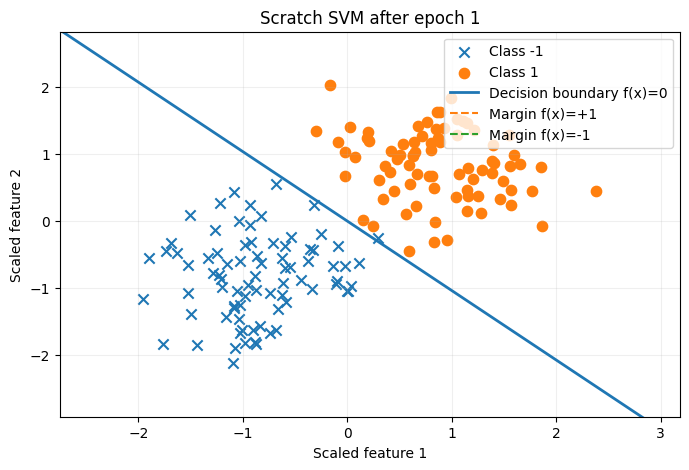

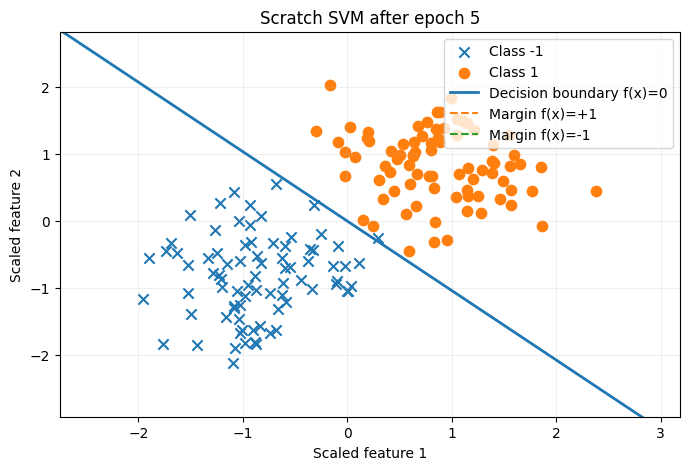

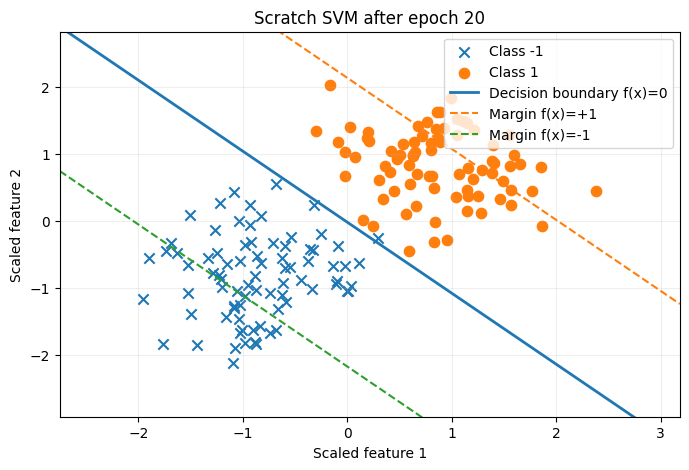

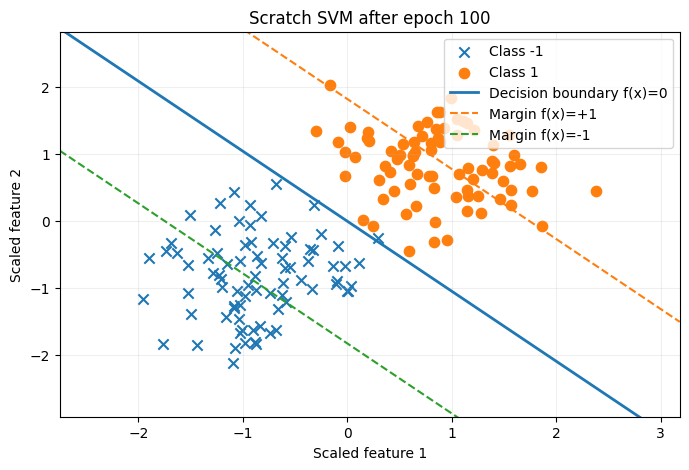

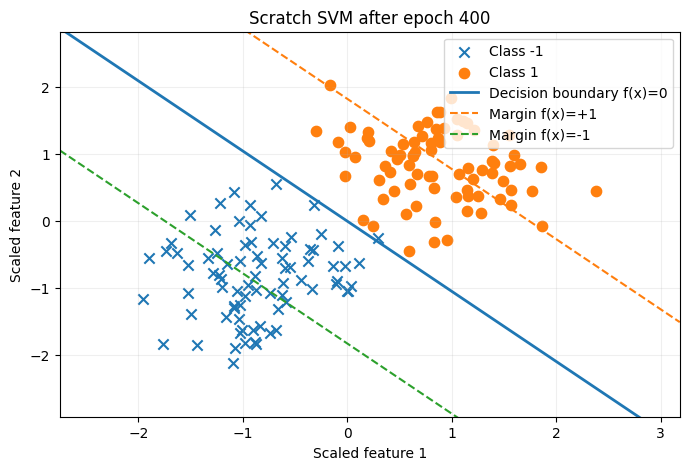

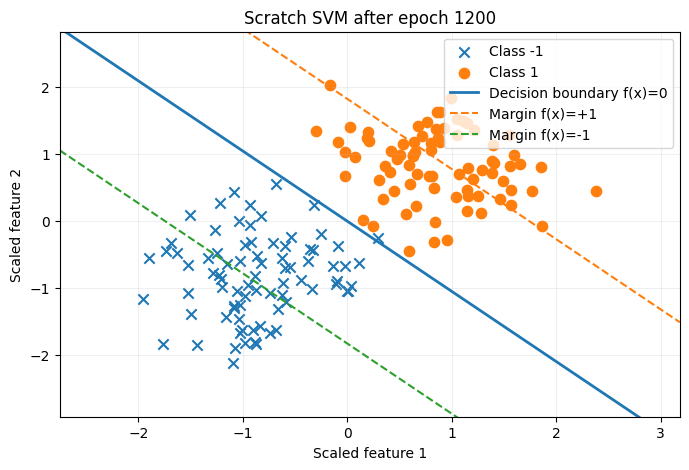

In [ ]:
for epoch in sorted(scratch_svm.snapshots_):
    w_epoch, b_epoch = scratch_svm.snapshots_[epoch]
    plot_linear_svm_geometry(
        X_lin_scaled,
        y_lin,
        w_epoch,
        b_epoch,
        title=f"Scratch SVM after epoch {epoch}"
    )

# Part IV — What does $C$ actually do?

Instead of memorizing “large C overfits, small C underfits,” inspect how the solution changes.

We add a difficult/outlier-like point and train several scratch models.

C= 0.05: accuracy=0.981, approx margin width=34.142, support candidates=161


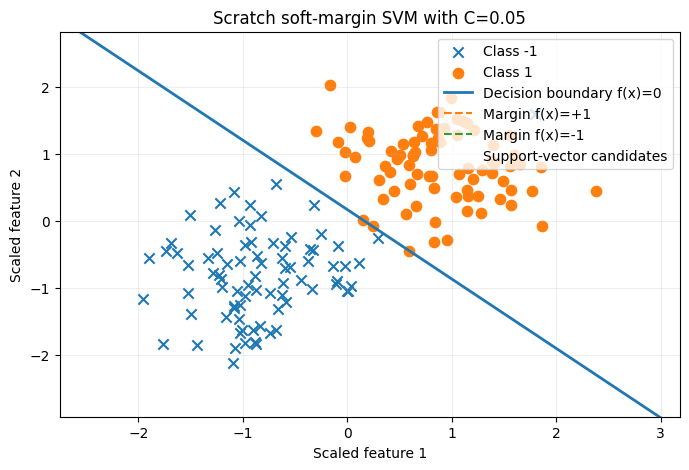

C=  1.0: accuracy=0.988, approx margin width=3.083, support candidates=122


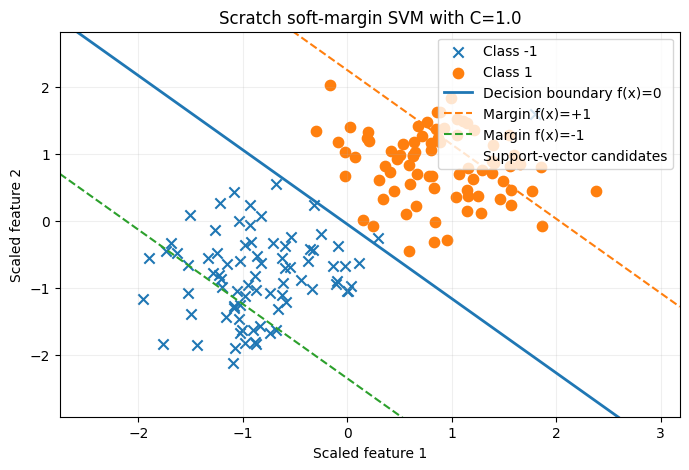

C= 20.0: accuracy=0.988, approx margin width=1.383, support candidates=34


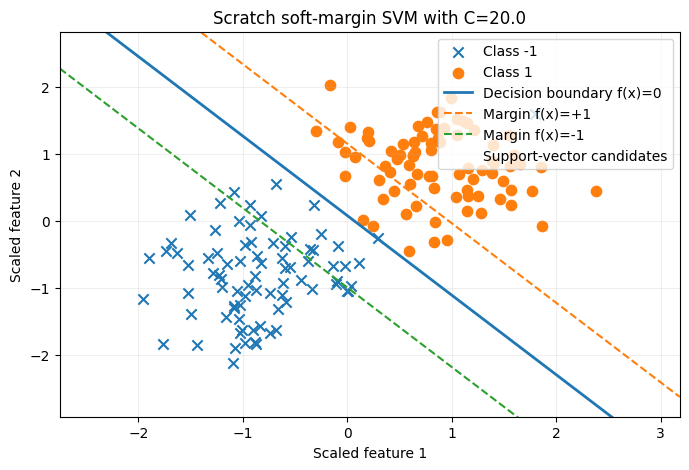

In [ ]:
X_c = X_lin_scaled.copy()
y_c = y_lin.copy()

# Add one deliberately difficult point on the opposite side.
X_c = np.vstack([X_c, [1.8, 1.6]])
y_c = np.append(y_c, -1)

for C_value in [0.05, 1.0, 20.0]:
    model_c = LinearSVMFromScratch(
        learning_rate=0.015,
        C=C_value,
        epochs=1500
    ).fit(X_c, y_c)

    mask_c = model_c.margin_mask(X_c, y_c, tolerance=0.05)
    train_acc = accuracy_score(y_c, model_c.predict(X_c))
    margin_width = 2 / np.linalg.norm(model_c.w_)

    print(f"C={C_value:>5}: accuracy={train_acc:.3f}, approx margin width={margin_width:.3f}, support candidates={mask_c.sum()}")
    plot_linear_svm_geometry(
        X_c, y_c, model_c.w_, model_c.b_,
        title=f"Scratch soft-margin SVM with C={C_value}",
        support_mask=mask_c
    )

# Part V — SVM using scikit-learn

Now we use a production-quality implementation.

For SVMs, feature scaling matters because distances and dot products drive the geometry. Scikit-learn explicitly recommends scaling input features for SVMs.

## 12. Linear `SVC` on the same standardized data

In [ ]:
svc_linear = SVC(kernel="linear", C=2.0)
svc_linear.fit(X_lin_scaled, y_lin)

print("Training accuracy:", round(svc_linear.score(X_lin_scaled, y_lin), 3))
print("Number of support vectors per class:", svc_linear.n_support_)
print("Total support vectors:", len(svc_linear.support_vectors_))
print("w from sklearn:", svc_linear.coef_[0])
print("b from sklearn:", svc_linear.intercept_[0])

Training accuracy: 0.994
Number of support vectors per class: [5 4]
Total support vectors: 9
w from sklearn: [2.45148781 1.559026  ]
b from sklearn: -0.2038999247003636


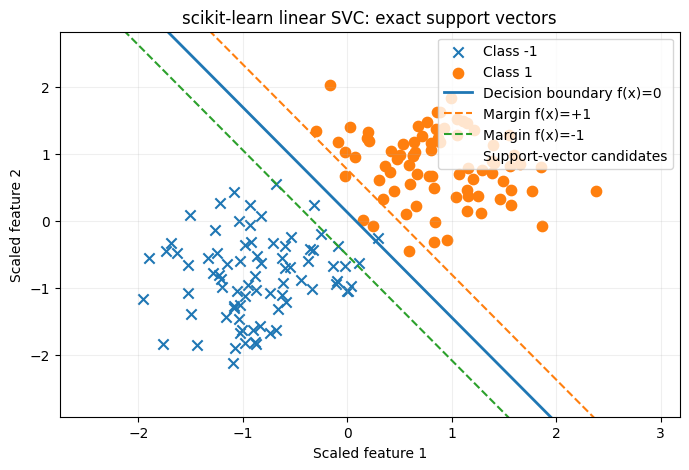

In [ ]:
sv_mask = np.zeros(len(X_lin_scaled), dtype=bool)
sv_mask[svc_linear.support_] = True

plot_linear_svm_geometry(
    X_lin_scaled,
    y_lin,
    svc_linear.coef_[0],
    svc_linear.intercept_[0],
    "scikit-learn linear SVC: exact support vectors",
    support_mask=sv_mask
)

## 13. Compare scratch vs library predictions

The parameters need not match exactly because the optimization procedures and objective scaling differ. The important question is whether they learn similar geometry and predictions.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Scratch SVM", "sklearn linear SVC"],
    "Training accuracy": [
        accuracy_score(y_lin, scratch_svm.predict(X_lin_scaled)),
        accuracy_score(y_lin, svc_linear.predict(X_lin_scaled))
    ]
})
comparison

,Model,Training accuracy
0,Scratch SVM,0.99375
1,sklearn linear SVC,0.99375


# Part VI — Kernel trick: nonlinear SVM

## 14. Why a kernel?

Suppose the original coordinates are not linearly separable. We can map the data into a richer feature space:

$$
\phi(\mathbf{x})
$$

and learn a linear separator there.

The kernel trick avoids explicitly constructing a potentially huge feature vector. Instead, it computes inner products in the transformed space through a kernel:

$$
K(\mathbf{x},\mathbf{z})=\phi(\mathbf{x})^T\phi(\mathbf{z})
$$

Common kernels:

**Linear**
$$K(\mathbf{x},\mathbf{z})=\mathbf{x}^T\mathbf{z}$$

**Polynomial**
$$K(\mathbf{x},\mathbf{z})=(\gamma\mathbf{x}^T\mathbf{z}+r)^d$$

**RBF / Gaussian**
$$K(\mathbf{x},\mathbf{z})=\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$$

### Why can kernels appear without explicitly computing $\phi(\mathbf{x})$?

In the dual view, the SVM decision function can be written as:

$$
f(\mathbf{x}) = \sum_i \alpha_i y_i K(\mathbf{x}_i,\mathbf{x}) + b
$$

Only training points with non-zero $\alpha_i$ contribute to the final classifier; these are the support vectors. Replacing an ordinary dot product with $K(\cdot,\cdot)$ lets the model act as if it were working in a richer feature space without constructing that feature space explicitly.

## 15. Visual intuition: circles become separable after adding a radius feature

This explicit transformation is **not** the RBF kernel. It is a simple geometric demonstration of why mapping to a higher-dimensional space can help.

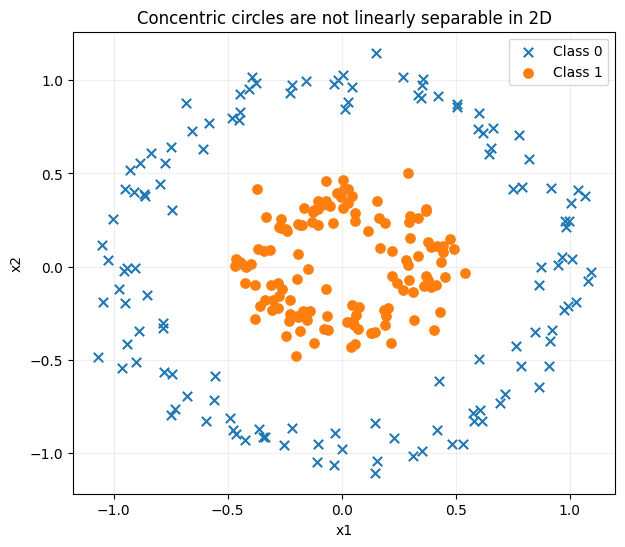

In [ ]:
X_circle, y_circle = make_circles(
    n_samples=260, factor=0.35, noise=0.08, random_state=42
)

plt.figure(figsize=(7, 6))
for label, marker in [(0, 'x'), (1, 'o')]:
    pts = X_circle[y_circle == label]
    plt.scatter(pts[:, 0], pts[:, 1], marker=marker, s=45, label=f"Class {label}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Concentric circles are not linearly separable in 2D")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

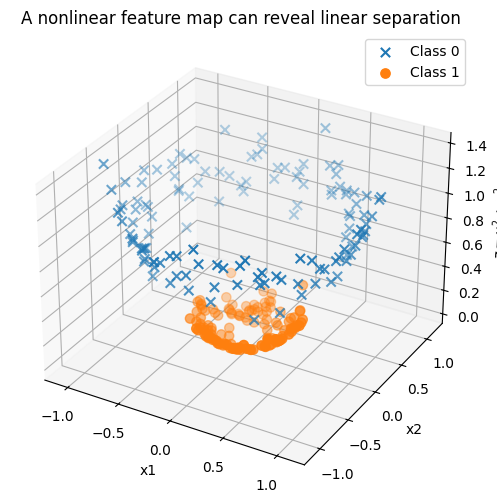

In [ ]:
z_radius = X_circle[:, 0]**2 + X_circle[:, 1]**2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for label, marker in [(0, 'x'), (1, 'o')]:
    idx = y_circle == label
    ax.scatter(
        X_circle[idx, 0], X_circle[idx, 1], z_radius[idx],
        marker=marker, s=45, label=f"Class {label}"
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel(r"$z=x_1^2+x_2^2$")
ax.set_title("A nonlinear feature map can reveal linear separation")
ax.legend()
plt.show()

## 16. Linear SVM vs RBF SVM on the same nonlinear circles

Linear SVM training accuracy: 0.615
RBF SVM training accuracy: 1.0


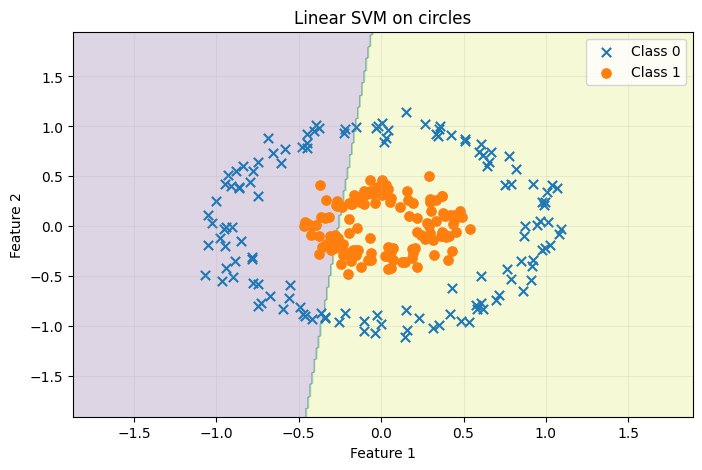

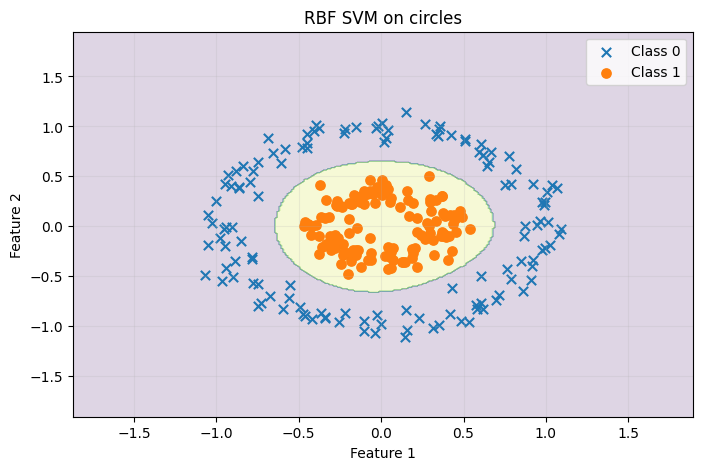

In [ ]:
linear_circle = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0))
])
rbf_circle = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=2.0, gamma="scale"))
])

linear_circle.fit(X_circle, y_circle)
rbf_circle.fit(X_circle, y_circle)

print("Linear SVM training accuracy:", round(linear_circle.score(X_circle, y_circle), 3))
print("RBF SVM training accuracy:", round(rbf_circle.score(X_circle, y_circle), 3))

plot_decision_regions(linear_circle, X_circle, y_circle, "Linear SVM on circles")
plot_decision_regions(rbf_circle, X_circle, y_circle, "RBF SVM on circles")

# Part VII — Understanding $\gamma$ in the RBF kernel

In

$$
K(\mathbf{x},\mathbf{z})=\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2),
$$

$\gamma$ controls how quickly similarity decays with distance.

- Smaller $\gamma$: each point has a wider region of influence → smoother boundary.
- Larger $\gamma$: influence becomes very local → highly flexible boundary.

The best value depends on scaling and the dataset; it should normally be tuned using validation/cross-validation.

gamma=0.1: training accuracy=0.880


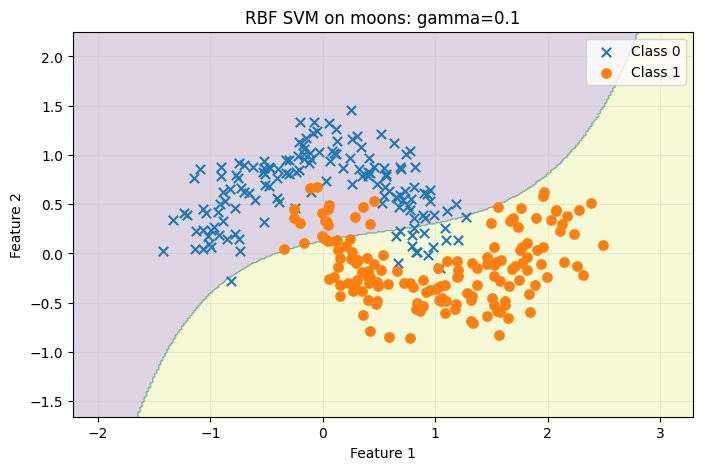

gamma=1.0: training accuracy=0.980


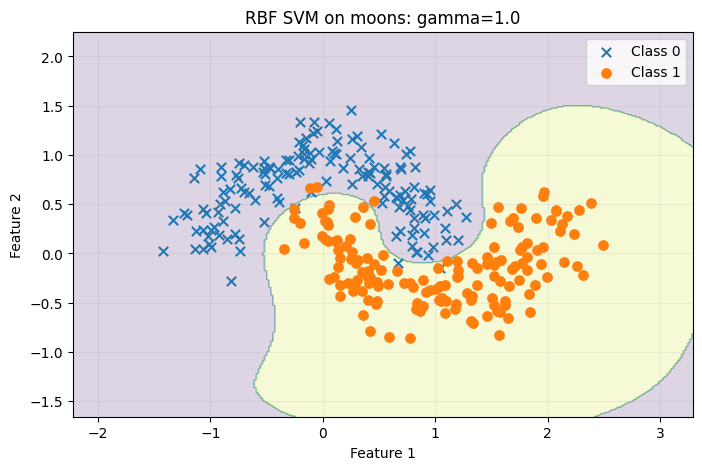

gamma=10.0: training accuracy=0.983


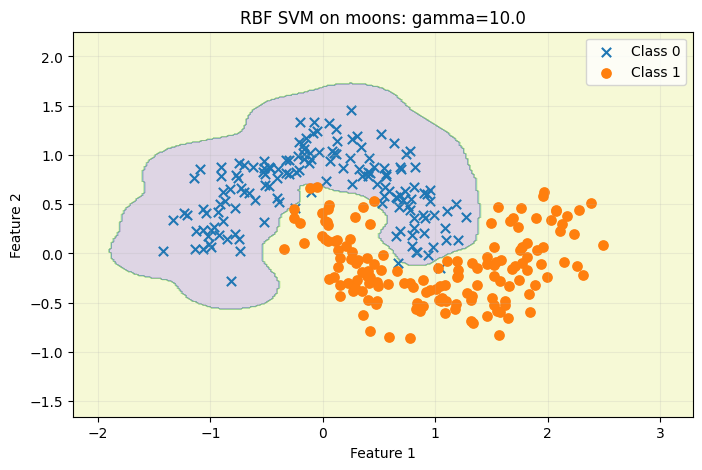

gamma=100.0: training accuracy=0.997


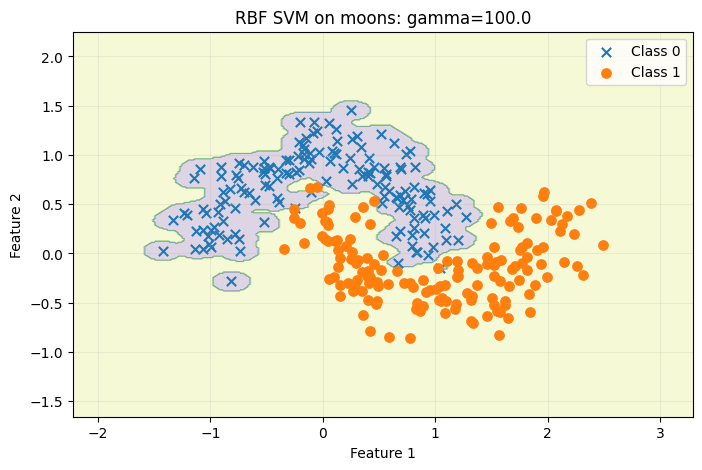

In [ ]:
for gamma_value in [0.1, 1.0, 10.0, 100.0]:
    gamma_model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=2.0, gamma=gamma_value))
    ])
    gamma_model.fit(X_moons, y_moons)
    print(f"gamma={gamma_value}: training accuracy={gamma_model.score(X_moons, y_moons):.3f}")
    plot_decision_regions(
        gamma_model,
        X_moons,
        y_moons,
        title=f"RBF SVM on moons: gamma={gamma_value}"
    )

# Part VIII — Why scaling is especially important for SVM

If one feature ranges from 0–1 and another from 0–100000, distance and dot-product calculations can be dominated by the large-scale feature even when it is not more important.

We demonstrate this by deliberately rescaling one axis of the moons dataset.

RBF-SVM accuracy without explicit scaling: 0.817
RBF-SVM accuracy with StandardScaler: 0.977


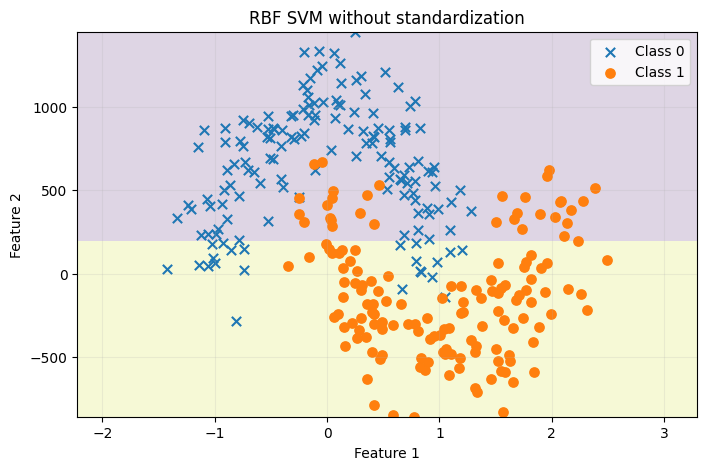

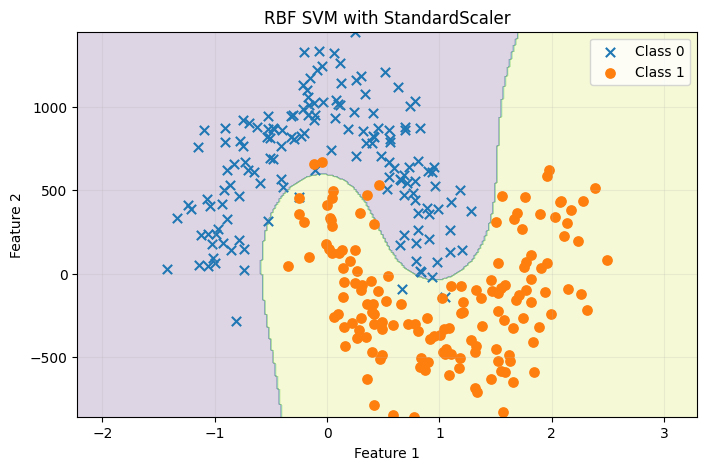

In [ ]:
X_bad_scale = X_moons.copy()
X_bad_scale[:, 1] *= 1000

svc_unscaled = SVC(kernel="rbf", C=2.0, gamma="scale")
svc_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=2.0, gamma="scale"))
])

svc_unscaled.fit(X_bad_scale, y_moons)
svc_scaled.fit(X_bad_scale, y_moons)

print("RBF-SVM accuracy without explicit scaling:", round(svc_unscaled.score(X_bad_scale, y_moons), 3))
print("RBF-SVM accuracy with StandardScaler:", round(svc_scaled.score(X_bad_scale, y_moons), 3))

plot_decision_regions(svc_unscaled, X_bad_scale, y_moons, "RBF SVM without standardization")
plot_decision_regions(svc_scaled, X_bad_scale, y_moons, "RBF SVM with StandardScaler")

# Part IX — Real-data workflow: breast cancer classification

We now move from 2D teaching datasets to a real dataset with many features.

Correct workflow:

1. Train/test split.
2. Put scaling **inside a pipeline** to avoid leakage.
3. Tune hyperparameters on the training data only.
4. Evaluate once on the held-out test set.

In [ ]:
data = load_breast_cancer()
X_real = pd.DataFrame(data.data, columns=data.feature_names)
y_real = pd.Series(data.target, name="target")

print("Shape:", X_real.shape)
print("Class names:", data.target_names)
print("Class counts:")
print(y_real.value_counts().sort_index())

Shape: (569, 30)
Class names: ['malignant' 'benign']
Class counts:
target
0    212
1    357
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_real, y_real,
    test_size=0.25,
    random_state=42,
    stratify=y_real
)

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.001, 0.01, 0.1]
}

grid = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best CV parameters:", grid.best_params_)
print("Best mean CV accuracy:", round(grid.best_score_, 4))

Best CV parameters: {'svc__C': 10, 'svc__gamma': 0.001}
Best mean CV accuracy: 0.9765


In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Held-out test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Held-out test accuracy: 0.979

Classification report:

              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97        53
      benign       0.98      0.99      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



                  Predicted malignant  Predicted benign
Actual malignant                   51                 2
Actual benign                       1                89


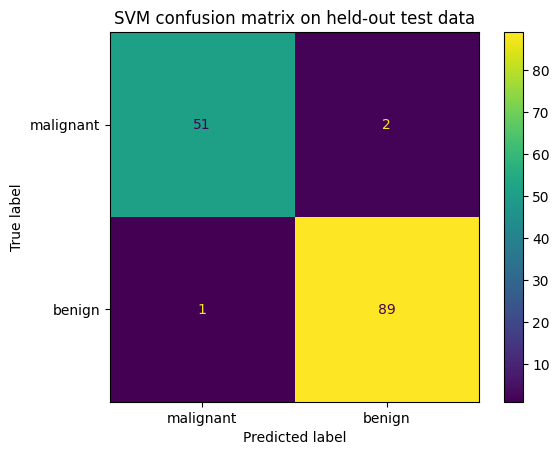

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in data.target_names],
    columns=[f"Predicted {name}" for name in data.target_names]
))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names).plot()
plt.title("SVM confusion matrix on held-out test data")
plt.show()

## 17. Inspect how $C$ and $\gamma$ affected cross-validation

This table lets students see hyperparameter tuning as evidence rather than magic.

In [ ]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_view = cv_results[[
    "param_svc__C",
    "param_svc__gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

cv_view.head(12)

,param_svc__C,param_svc__gamma,mean_test_score,std_test_score,rank_test_score
9,10.0,0.001,0.976525,0.016638,1
6,1.0,0.01,0.971819,0.015975,2
13,100.0,0.001,0.969466,0.009453,3
4,1.0,scale,0.964733,0.022351,4
14,100.0,0.01,0.962435,0.025131,5
10,10.0,0.01,0.962408,0.013777,6
8,10.0,scale,0.960055,0.020557,7
12,100.0,scale,0.953078,0.024614,8
5,1.0,0.001,0.945992,0.014174,9
7,1.0,0.1,0.945964,0.012127,10
